Problem Statement : "Understanding Customer Churn in a Telecom Company: Identifying Key Factors Affecting Customer Retention"

In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [46]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,DSL,Yes,No,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,DSL,No,Yes,No,No,No,One year,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,DSL,Yes,No,No,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,DSL,No,Yes,Yes,No,No,One year,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Fiber optic,No,No,No,No,No,Month-to-month,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,DSL,No,Yes,Yes,Yes,Yes,One year,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Fiber optic,Yes,Yes,No,Yes,Yes,One year,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,DSL,No,No,No,No,No,Month-to-month,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Fiber optic,No,No,No,No,No,Month-to-month,Mailed check,74.40,306.6,Yes


In [47]:
df.shape

(7043, 17)

In [48]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'InternetService', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [49]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
InternetService      object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [50]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(" ", np.nan))
df.dropna(subset=["TotalCharges"], inplace=True)



In [51]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
InternetService      object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [52]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [53]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7032, dtype: bool

In [54]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
InternetService     0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [55]:
df.drop(columns=['customerID','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','TotalCharges'], inplace=True)

In [56]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,Contract,PaymentMethod,MonthlyCharges,Churn
0,Female,0,Yes,No,1,DSL,Month-to-month,Electronic check,29.85,No
1,Male,0,No,No,34,DSL,One year,Mailed check,56.95,No
2,Male,0,No,No,2,DSL,Month-to-month,Mailed check,53.85,Yes
3,Male,0,No,No,45,DSL,One year,Bank transfer (automatic),42.30,No
4,Female,0,No,No,2,Fiber optic,Month-to-month,Electronic check,70.70,Yes


<Axes: xlabel='SeniorCitizen'>

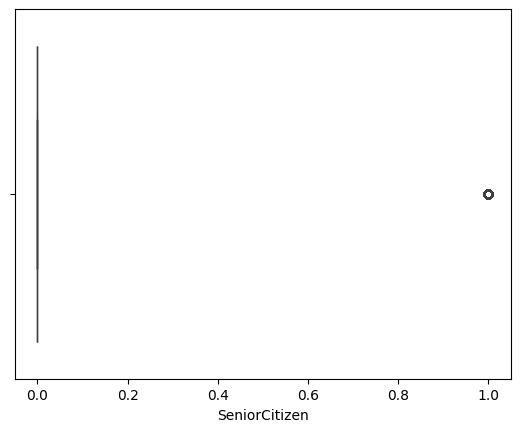

In [58]:
sns.boxplot(x="SeniorCitizen", data=df)

<Axes: xlabel='tenure'>

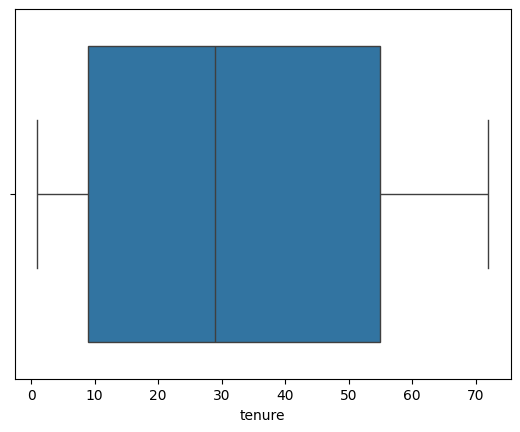

In [59]:
sns.boxplot(x="tenure", data=df)

<Axes: xlabel='MonthlyCharges'>

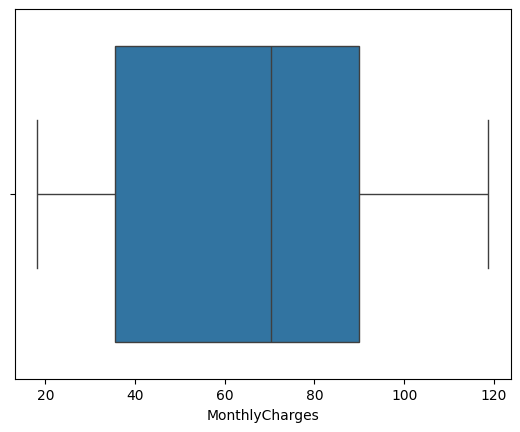

In [60]:
sns.boxplot(x="MonthlyCharges", data=df)

In [61]:
df["gender"].value_counts()


gender
Male      3549
Female    3483
Name: count, dtype: int64

In [62]:
df[df["Churn"] == "Yes"]["gender"].value_counts()


gender
Female    939
Male      930
Name: count, dtype: int64

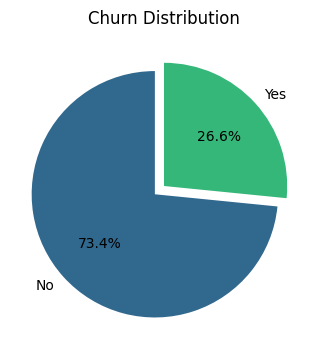

In [63]:


plt.figure(figsize=(6, 4))  

colors = sns.color_palette("viridis", 2)

churn_counts = df["Churn"].value_counts()

plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', 
        colors=colors, explode=[0.1, 0], startangle=90)

plt.title("Churn Distribution")  
plt.show()  


Observation : Most customers stay, but some leave (churn).


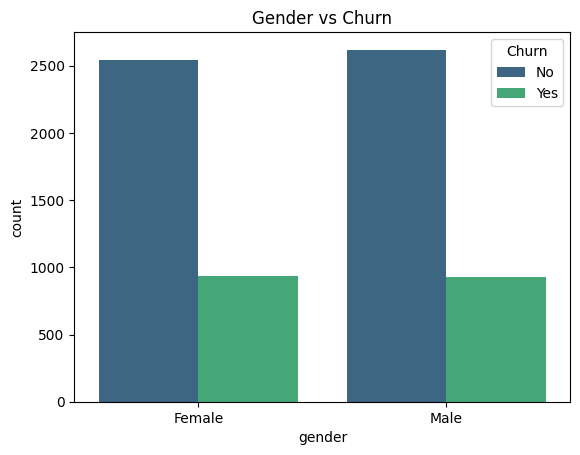

In [64]:

sns.countplot(data=df, x="gender", hue="Churn", palette="viridis")
plt.title("Gender vs Churn")
plt.show()


Observation : Female customers churn slightly more than males, but the difference is very small Since the gap is minimal, gender does not significantly impact churn behavior.

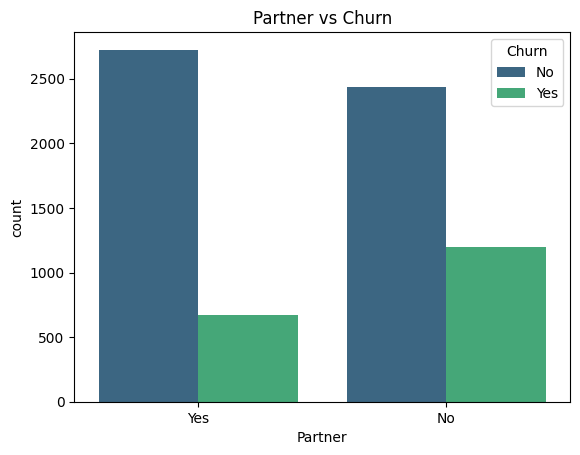

In [65]:

sns.countplot(data=df, x="Partner", hue="Churn", palette="viridis")
plt.title("Partner vs Churn")
plt.show()


 Observation : Single people leave more than those with partners.

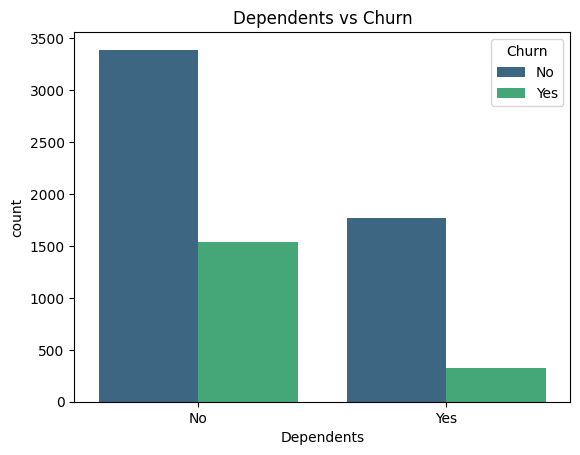

In [66]:

sns.countplot(data=df, x="Dependents", hue="Churn", palette="viridis")
plt.title("Dependents vs Churn")
plt.show()

Observation : no-dependent customers churn more

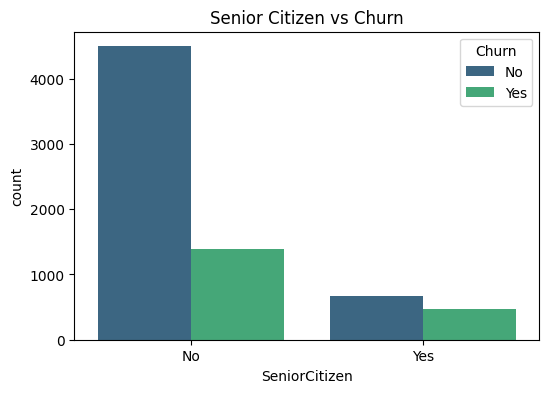

In [67]:

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="SeniorCitizen", hue="Churn", palette="viridis")
plt.title("Senior Citizen vs Churn")
plt.xticks(ticks=[0, 1], labels=["No", "Yes"])
plt.show()


Observation : Senior citizens have a slightly lower churn rate compared to younger customers.

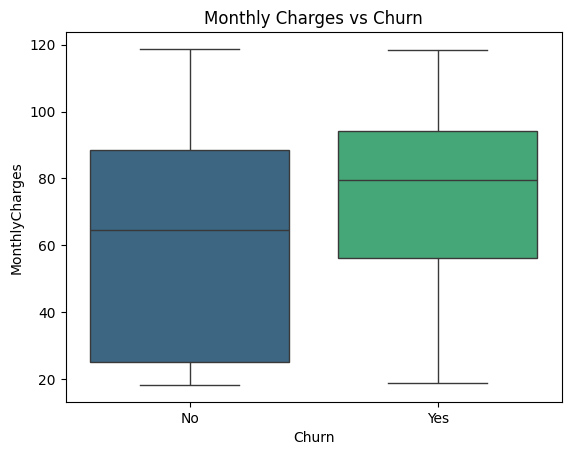

In [68]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette="viridis")
plt.title("Monthly Charges vs Churn")
plt.show()



Observation : Customers with higher monthly charges seem more likely to churn. This indicates that expensive plans might lead to higher customer dropouts.

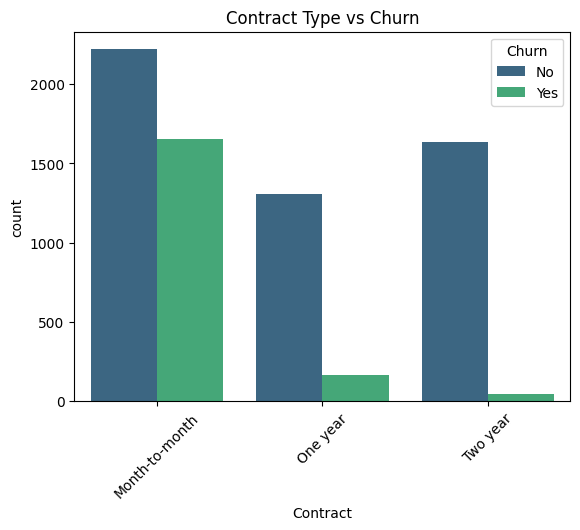

In [69]:

sns.countplot(data=df, x="Contract", hue="Churn", palette="viridis")
plt.title("Contract Type vs Churn")
plt.xticks(rotation=45)
plt.show()


Observation : Month-to-month contract customers leave the most. Long-term contract customers stay longer.

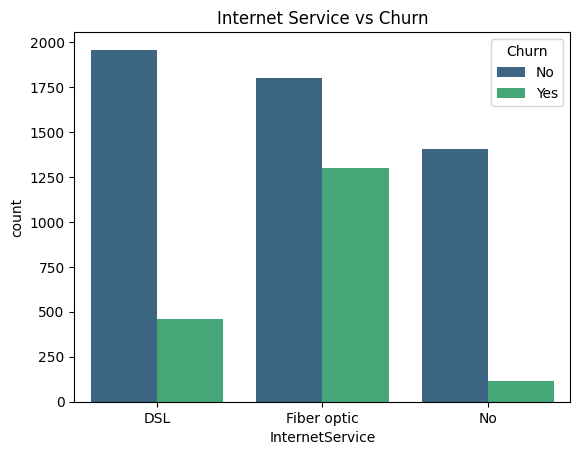

In [70]:

sns.countplot(data=df, x="InternetService", hue="Churn", palette="viridis")
plt.title("Internet Service vs Churn")
plt.show()


Observation : Fiber optic users leave more (maybe expensive or service issues). DSL users stay longer.

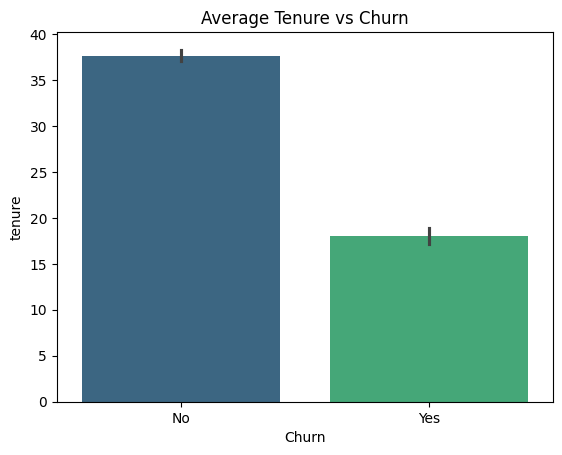

In [72]:

sns.barplot(data=df, x="Churn", y="tenure", palette="viridis")
plt.title("Average Tenure vs Churn")
plt.show()


Observation :  New customers leave quickly.

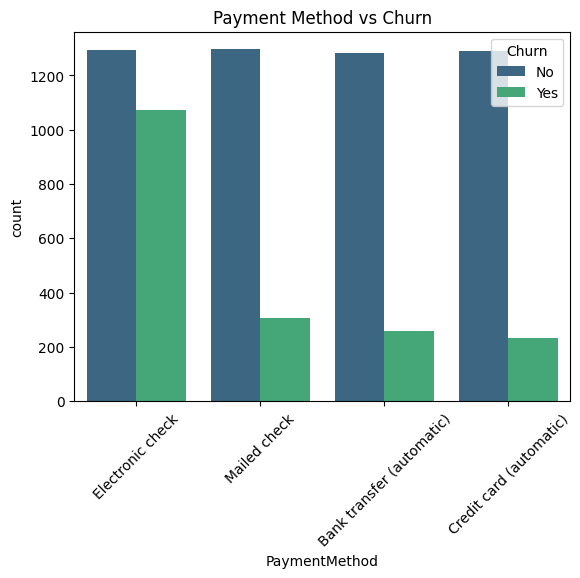

In [73]:

sns.countplot(data=df, x="PaymentMethod", hue="Churn", palette="viridis")
plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.show()


Observation : Electronic check users leave the most. Auto-pay users stay longer.

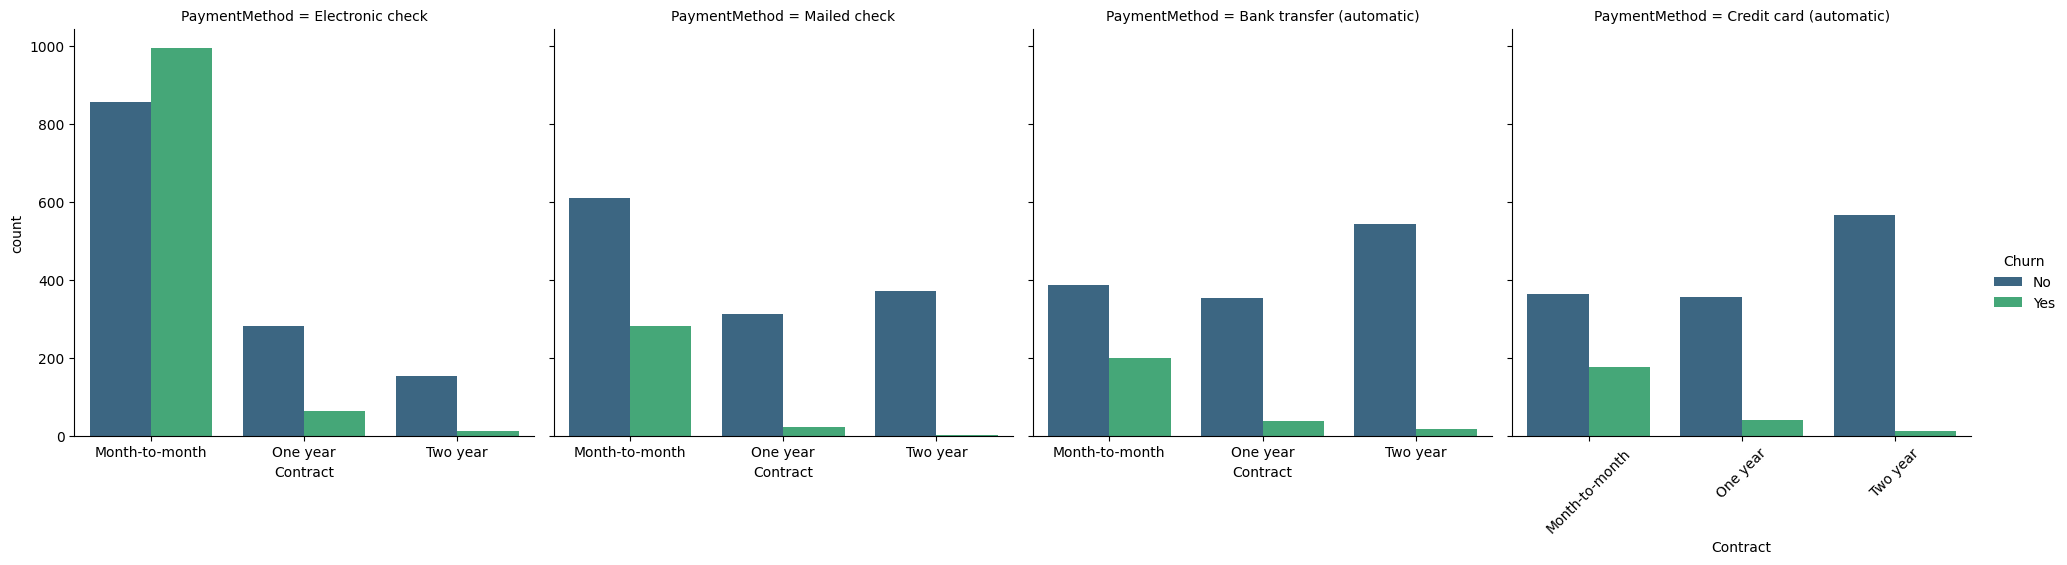

In [74]:

sns.catplot(data=df, x="Contract", hue="Churn", col="PaymentMethod", kind="count", palette="viridis")
plt.xticks(rotation=45)
plt.show()


Observation : Customers on month-to-month contracts using electronic checks have the highest churn rate.
️Long-term contract customers with auto-pay options show significantly lower churn rates.

Conclusion :

Single, younger, and no-dependent customers churn more, while seniors prefer stability
Month-to-month contracts and electronic check payments lead to higher churn
Higher monthly charges and fiber optic services see more churn, likely due to cost.
New customers leave quickly, so early engagement is crucial.

In [75]:
from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder(sparse_output=False)

encoded_data=encoder.fit_transform(df[['gender','Partner','Dependents','InternetService','Contract','PaymentMethod','Churn']])

df2=pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['gender','Partner','Dependents','InternetService','Contract','PaymentMethod','Churn']))

result=pd.concat([df,df2], axis=1)
result


,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,Contract,PaymentMethod,MonthlyCharges,Churn,...,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes
0,Female,0.0,Yes,No,1.0,DSL,Month-to-month,Electronic check,29.85,No,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,Male,0.0,No,No,34.0,DSL,One year,Mailed check,56.95,No,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,Male,0.0,No,No,2.0,DSL,Month-to-month,Mailed check,53.85,Yes,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,Male,0.0,No,No,45.0,DSL,One year,Bank transfer (automatic),42.30,No,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,Female,0.0,No,No,2.0,Fiber optic,Month-to-month,Electronic check,70.70,Yes,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4380,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
5218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
6670,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [76]:
result = pd.get_dummies(df,dtype=int,drop_first=True)
result

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,0,1,0,0,0,0,0,0,1,0,0
1,0,34,56.95,1,0,0,0,0,1,0,0,0,1,0
2,0,2,53.85,1,0,0,0,0,0,0,0,0,1,1
3,0,45,42.30,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,0,0,0,1,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1,1,1,0,0,1,0,0,0,1,0
7039,0,72,103.20,0,1,1,1,0,1,0,1,0,0,0
7040,0,11,29.60,0,1,1,0,0,0,0,0,1,0,0
7041,1,4,74.40,1,1,0,1,0,0,0,0,0,1,1


In [77]:
result.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'gender_Male',
       'Partner_Yes', 'Dependents_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='object')

In [83]:
# Step 1: Convert all text columns to numbers using get_dummies
X = pd.get_dummies(df.drop(columns=['Churn']), drop_first=True)
Y = df['Churn']


In [84]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [85]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)


LogisticRegression(max_iter=1000)

In [86]:
y_pred = model.predict(x_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7860696517412935
